In [1]:
import matplotlib.pyplot as plt

import pandas as pd

In [3]:
adam_64 = pd.read_csv("./train_loss.csv")
adaboba_32 = pd.read_csv("./train_loss (1).csv")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import itertools
from pathlib import Path
import itertools
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba": "#ff6b6b",
    "sgd_seesaw": "#2ca02c",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["value"] = df["value"].astype(float)
    df["run"] = name
    df["ema"] = df["value"].ewm(span=20, adjust=False).mean()
    return df

sgboba = load_loss("sgd-aboba-2-bs.csv", "sgboba")
seesaw = load_loss("sgd-seesaw-bs-3.csv", "sgd_seesaw")
df = pd.concat([sgboba, seesaw], ignore_index=True)
xlim = int(df["step"].max() + 1)
Path("graphics").mkdir(parents=True, exist_ok=True)

def make_plots_epochs_time(methods, title='', key='value', xlim=100, met='gradient_norm', dataset='hetero'):
    fig = plt.figure(figsize=(8, 6))
    plt.gca().set_facecolor('#519dfc')
    plt.gca().patch.set_alpha(0.15)

    marker = itertools.cycle(('o', 's', '*', '^', 'h'))
    color = itertools.cycle(('forestgreen', 'darkorange', 'crimson', 'darkmagenta', 'turquoise'))

    for method in methods:
        if key != 'test_acc':
            plt.plot(np.array(method['time']), np.array(method[key]),
                         linewidth=3, color=next(color),
                         marker=next(marker), markersize=10, markevery=5, markeredgecolor='black',
                         label=method['label'])
        else:
            plt.plot(np.array(method['time']), np.array(method[key]),
                     linewidth=3, color=next(color),
                     marker=next(marker), markersize=10, markevery=5, markeredgecolor='black',
                     label=method['label'])

    if key != 'test_acc':
        plt.legend(loc='upper left', fontsize=20)
    else:
        plt.legend(loc='lower right', fontsize=20)

    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

    plt.xlabel('Step', fontsize=30)
    if key in ('test_loss', 'ema', 'value'):
        plt.ylabel('Batch size', fontsize=30)
    if key == 'test_acc':
        plt.ylabel('Accuracy', fontsize=30)

    plt.xlim(0, xlim)

    plt.grid(color='#6d7175', linestyle='--', linewidth=0.7, alpha=0.9)
    plt.savefig('graphics/' + key + '_' + str(met) + '_' + str(dataset) + '.pdf', format='pdf', bbox_inches='tight')
    plt.show()

methods = [
    {"time": sgboba["step"], "ema": sgboba["ema"], "value": sgboba["value"], "label": "sgboba"},
    {"time": seesaw["step"], "ema": seesaw["ema"], "value": seesaw["value"], "label": "sgd_seesaw"},
]

make_plots_epochs_time(methods, title="Batch size vs step", key="ema", xlim=xlim, met="bs", dataset="sgd")


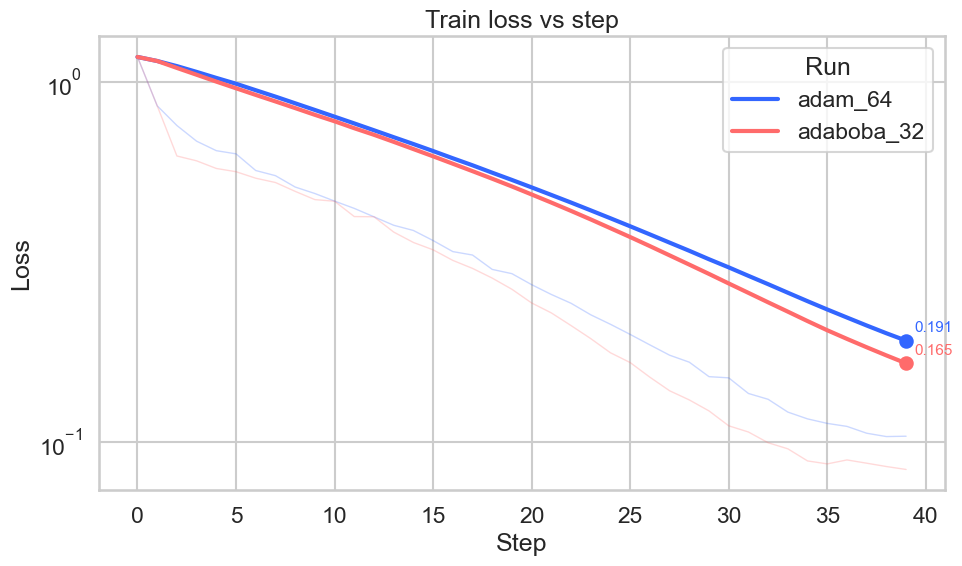

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {"adam_64": "#3366ff", "adaboba_32": "#ff6b6b"}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["value"] = df["value"].astype(float)
    df["run"] = name
    df["ema"] = df["value"].ewm(span=20, adjust=False).mean()
    return df

adam = load_loss("train_loss.csv", "adam_64")
adaboba = load_loss("train_loss (1).csv", "adaboba_32")
df = pd.concat([adam, adaboba], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             alpha=0.25, lw=1, legend=False, ax=ax, zorder=1)
sns.lineplot(data=df, x="step", y="ema", hue="run", palette=palette,
             lw=3, legend=True, ax=ax, zorder=2)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["ema"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['ema']:.3f}", (last["step"], last["ema"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(
    title="Train loss vs step",
    xlabel="Step",
    ylabel="Loss",
    yscale="log",
)
ax.legend(title="Run", loc="upper right")
plt.tight_layout()
plt.show()


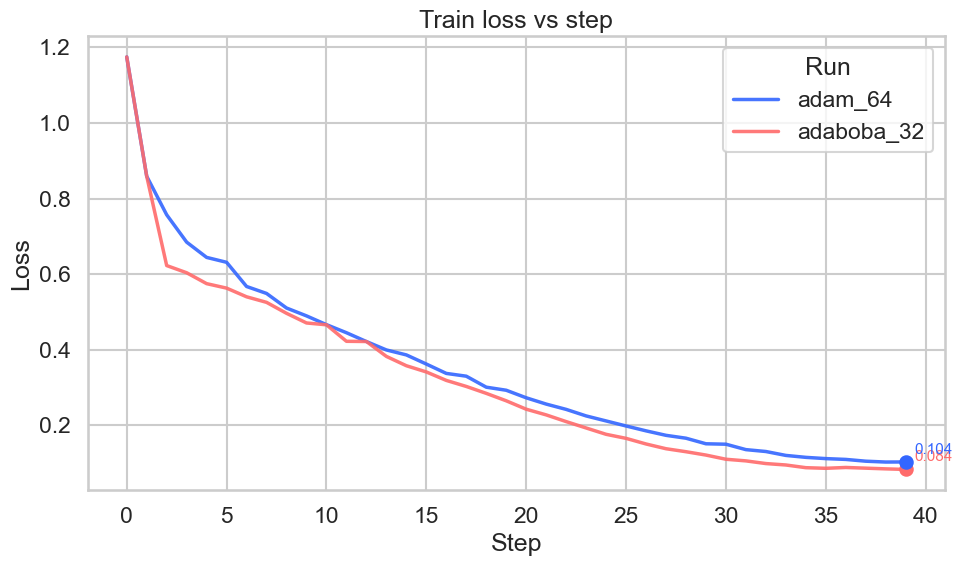

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {"adam_64": "#3366ff", "adaboba_32": "#ff6b6b"}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

adam = load_loss("train_loss.csv", "adam_64")
adaboba = load_loss("train_loss (1).csv", "adaboba_32")
df = pd.concat([adam, adaboba], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
plt.tight_layout()
plt.show()


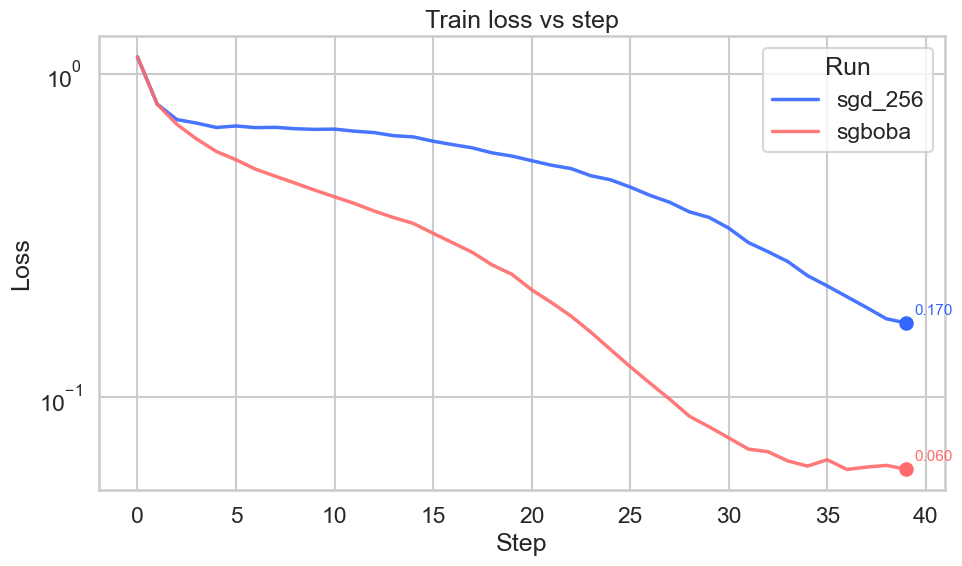

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {"sgd_256": "#3366ff", "sgboba": "#ff6b6b"}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

adam = load_loss("sgd-64.csv", "sgd_256")
adaboba = load_loss("sgd-aboba.csv", "sgboba")
df = pd.concat([adam, adaboba], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
plt.tight_layout()
plt.show()


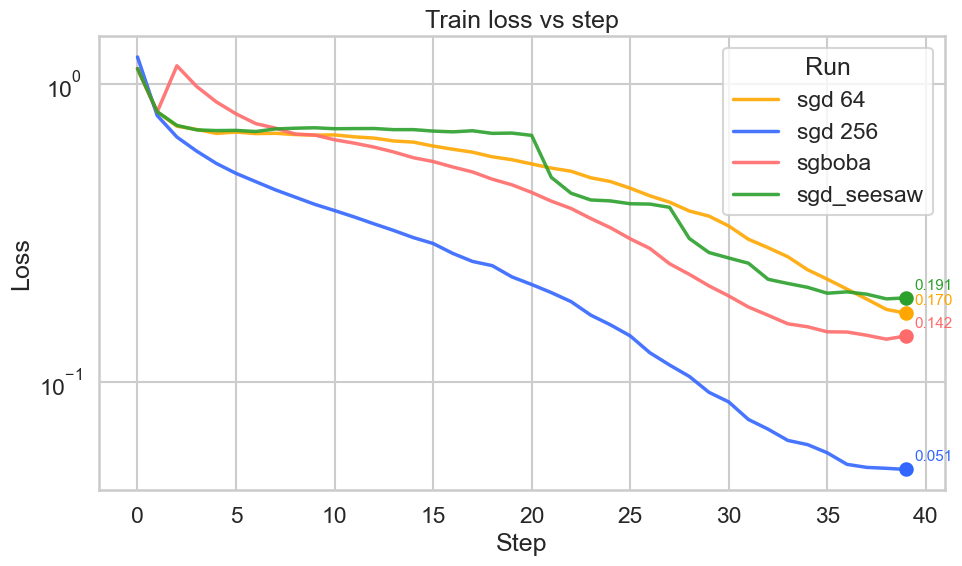

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgd 256": "#3366ff",
    "sgboba": "#ff6b6b",
    "sgd_seesaw": "#2ca02c",
    "sgd 64": "#ffa600",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgd256  = load_loss("sgd-256.csv", "sgd 256")
sgd64  = load_loss("sgd-64.csv", "sgd 64")
sgboba  = load_loss("sgd-aboba-2.csv", "sgboba")
seesaw  = load_loss("sgd-seesaw.csv", "sgd_seesaw")
df = pd.concat([sgd64, sgd256, sgboba, seesaw], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
plt.tight_layout()
plt.show()


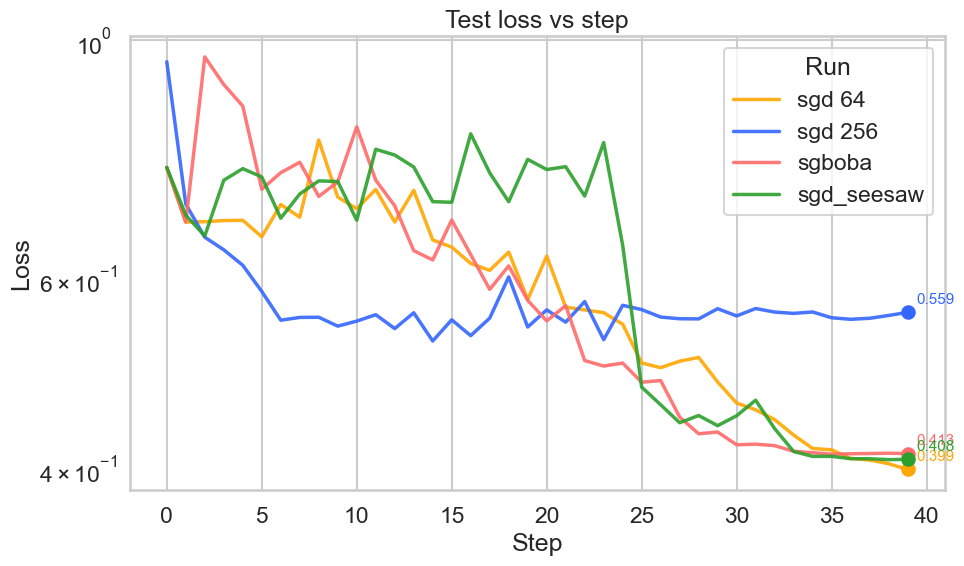

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgd 256": "#3366ff",
    "sgboba": "#ff6b6b",
    "sgd_seesaw": "#2ca02c",
    "sgd 64": "#ffa600",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgd256  = load_loss("sgd-256-test.csv", "sgd 256")
sgd64 = load_loss("sgd-64-test.csv", "sgd 64")
sgboba  = load_loss("sgd-aboba-2-test.csv", "sgboba")
seesaw  = load_loss("sgd-seesaw-test-3.csv", "sgd_seesaw")
df = pd.concat([sgd64, sgd256, sgboba, seesaw], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Test loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
plt.tight_layout()
plt.show()


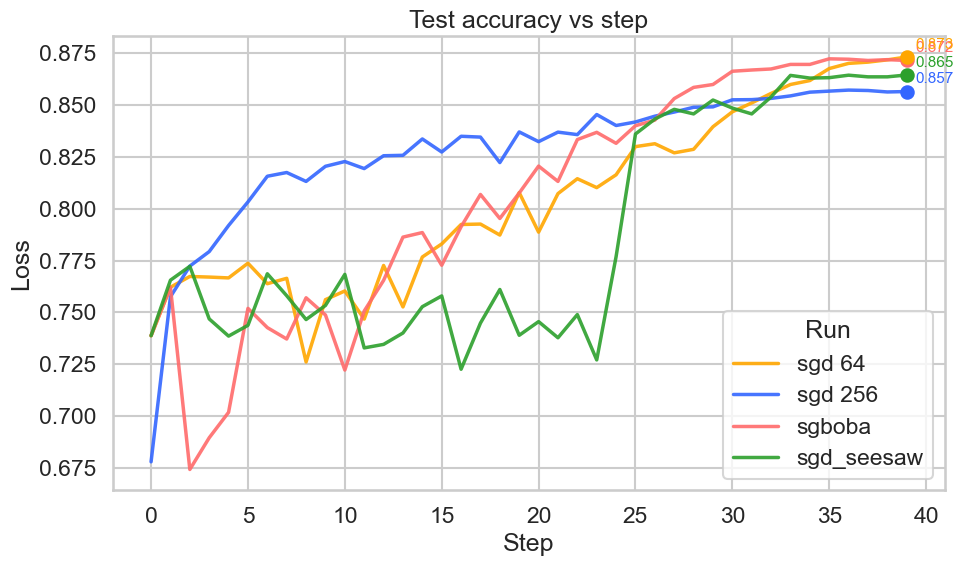

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgd 256": "#3366ff",
    "sgboba": "#ff6b6b",
    "sgd_seesaw": "#2ca02c",
    "sgd 64": "#ffa600",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgd64 = load_loss("sgd-64-acc.csv", "sgd 64")
sgd256  = load_loss("sgd-256-acc.csv", "sgd 256")
sgboba  = load_loss("sgd-aboba-2-acc.csv", "sgboba")
seesaw  = load_loss("sgd-seesaw-acc-3.csv", "sgd_seesaw")
df = pd.concat([sgd64, sgd256, sgboba, seesaw], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Test accuracy vs step", xlabel="Step", ylabel="Loss",)# yscale="log")
ax.legend(title="Run", loc="lower right")
plt.tight_layout()
plt.show()


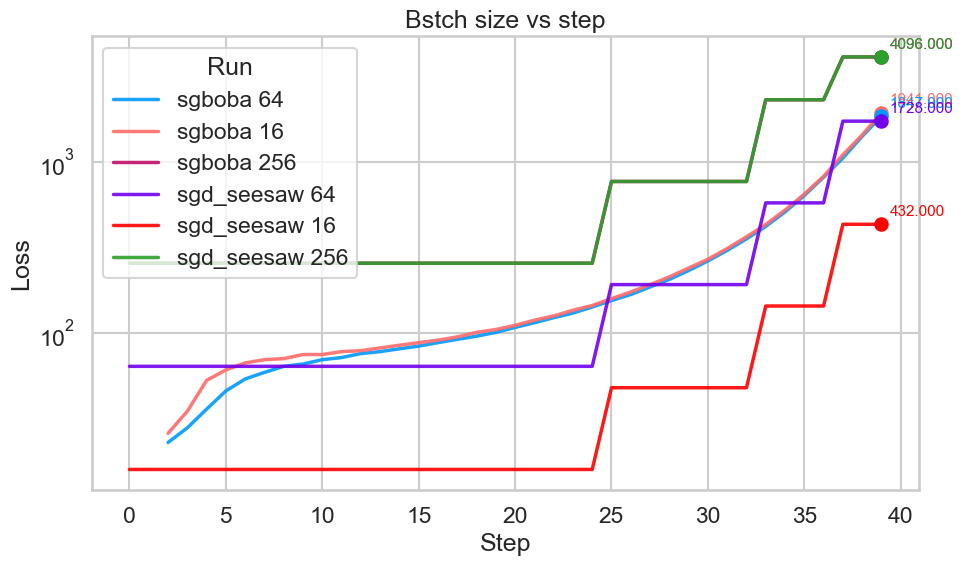

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#c00d6a",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#2ca02c",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgboba  = load_loss("sgd-aboba-2-bs.csv", "sgboba 64")
sgboba16 = load_loss("sgd-aboba-bs-from-16.csv", "sgboba 16")
sgboba256 = load_loss("sgd-aboba-bs-from-256.csv", "sgboba 256")

seesaw  = load_loss("sgd-seesaw-bs-3.csv", "sgd_seesaw 64")
seesaw16  = load_loss("sgd-seesaw-3-bs-from-16.csv", "sgd_seesaw 16")
seesaw256  = load_loss("sgd-seesaw-bs-3-from-256.csv", "sgd_seesaw 256")

df = pd.concat([sgboba, sgboba16, sgboba256, seesaw, seesaw16, seesaw256], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Bstch size vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper left")
plt.tight_layout()
plt.show()


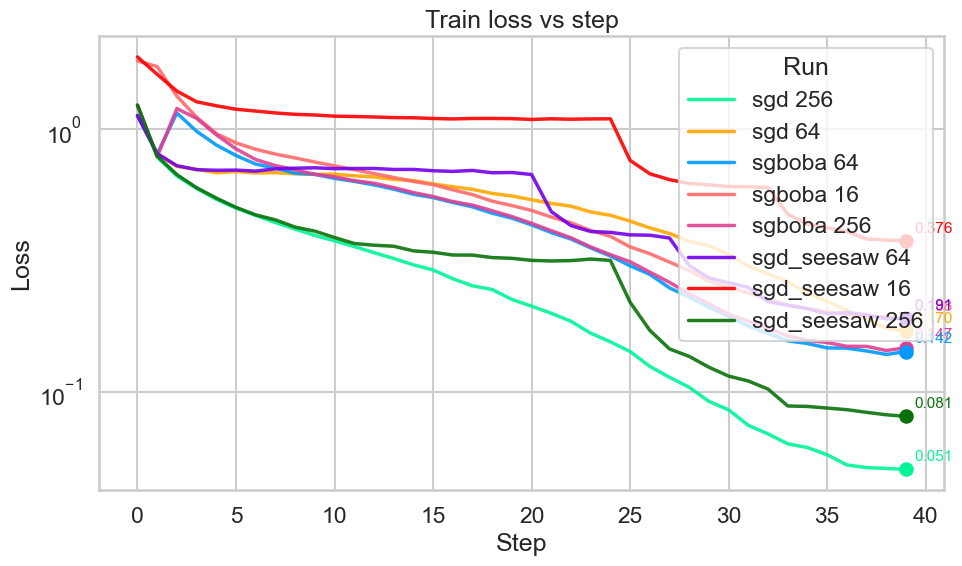

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",

    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgd256  = load_loss("sgd-256.csv", "sgd 256")
sgd64 = load_loss("sgd-64.csv", "sgd 64")

sgboba  = load_loss("sgd-aboba-2.csv", "sgboba 64")
sgboba16 = load_loss("sgd-aboba-from-16.csv", "sgboba 16")
sgboba256 = load_loss("sgd-aboba-from-256.csv", "sgboba 256")

seesaw  = load_loss("sgd-seesaw.csv", "sgd_seesaw 64")
seesaw16  = load_loss("sgd-seesaw-3-from-16.csv", "sgd_seesaw 16")
seesaw256  = load_loss("sgd-seesaw-3-from-256.csv", "sgd_seesaw 256")

df = pd.concat([sgd256, sgd64, sgboba, sgboba16, sgboba256, seesaw, seesaw16, seesaw256], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
plt.tight_layout()
plt.show()


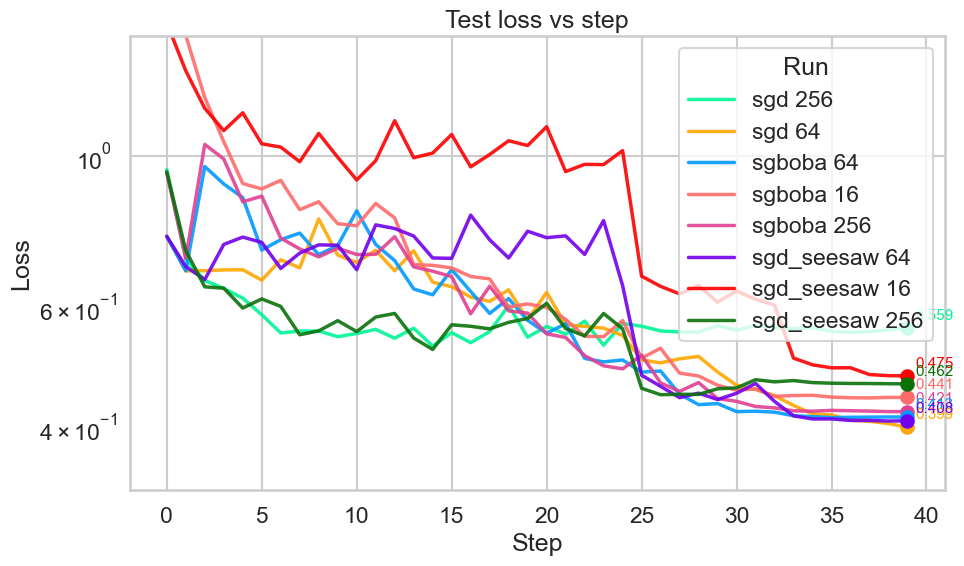

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",

    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgd256  = load_loss("sgd-256-test.csv", "sgd 256")
sgd64 = load_loss("sgd-64-test.csv", "sgd 64")

sgboba  = load_loss("sgd-aboba-2-test.csv", "sgboba 64")
sgboba16 = load_loss("sgd-aboba-test-from-16.csv", "sgboba 16")
sgboba256 = load_loss("sgd-aboba-test-from-256.csv", "sgboba 256")

seesaw  = load_loss("sgd-seesaw-test-3.csv", "sgd_seesaw 64")
seesaw16  = load_loss("sgd-seesaw-3-test-from-16.csv", "sgd_seesaw 16")
seesaw256  = load_loss("sgd-seesaw-test-3-from-256.csv", "sgd_seesaw 256")

df = pd.concat([sgd256, sgd64, sgboba, sgboba16, sgboba256, seesaw, seesaw16, seesaw256], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Test loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)

plt.tight_layout()
plt.show()


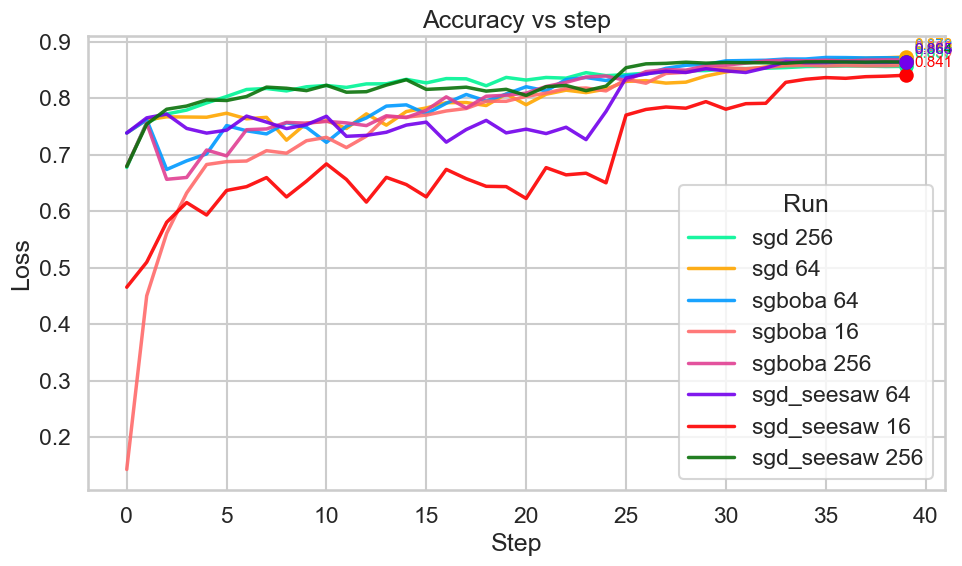

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",

    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgd256  = load_loss("sgd-256-acc.csv", "sgd 256")
sgd64 = load_loss("sgd-64-acc.csv", "sgd 64")

sgboba  = load_loss("sgd-aboba-2-acc.csv", "sgboba 64")
sgboba16 = load_loss("sgd-aboba-acc-from-16.csv", "sgboba 16")
sgboba256 = load_loss("sgd-aboba-acc-from-256.csv", "sgboba 256")

seesaw  = load_loss("sgd-seesaw-acc-3.csv", "sgd_seesaw 64")
seesaw16  = load_loss("sgd-seesaw-3-acc-from-16.csv", "sgd_seesaw 16")
seesaw256  = load_loss("sgd-seesaw-acc-3-from-256.csv", "sgd_seesaw 256")

df = pd.concat([sgd256, sgd64, sgboba, sgboba16, sgboba256, seesaw, seesaw16, seesaw256], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df, x="step", y="value", hue="run", palette=palette,
             lw=2.5, alpha=0.9, ax=ax)

for name, group in df.groupby("run"):
    last = group.iloc[-1]
    ax.scatter(last["step"], last["value"], color=palette[name], s=80, zorder=3)
    ax.annotate(f"{last['value']:.3f}", (last["step"], last["value"]),
                textcoords="offset points", xytext=(6, 6), ha="left",
                color=palette[name], fontsize=11)

ax.set(title="Accuracy vs step", xlabel="Step", ylabel="Loss",)# yscale="log")
ax.legend(title="Run", loc="lower right")
#ax.set_ylim(top=1.5)

plt.tight_layout()
plt.show()


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_10441/3416702346.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


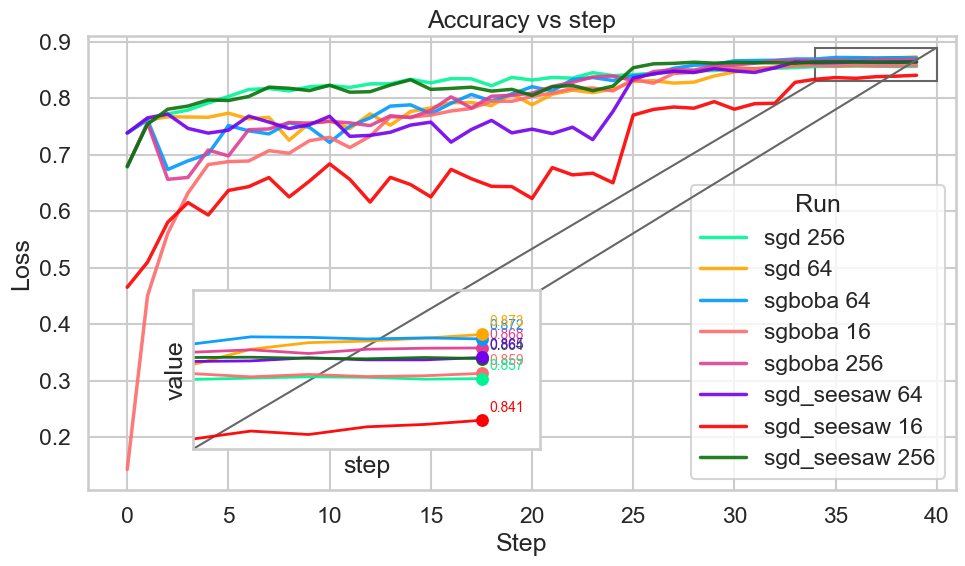

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = name
    return df

sgd256  = load_loss("sgd-256-acc.csv", "sgd 256")
sgd64   = load_loss("sgd-64-acc.csv", "sgd 64")

sgboba    = load_loss("sgd-aboba-2-acc.csv", "sgboba 64")
sgboba16  = load_loss("sgd-aboba-acc-from-16.csv", "sgboba 16")
sgboba256 = load_loss("sgd-aboba-acc-from-256.csv", "sgboba 256")

seesaw    = load_loss("sgd-seesaw-acc-3.csv", "sgd_seesaw 64")
seesaw16  = load_loss("sgd-seesaw-3-acc-from-16.csv", "sgd_seesaw 16")
seesaw256 = load_loss("sgd-seesaw-acc-3-from-256.csv", "sgd_seesaw 256")

df = pd.concat(
    [sgd256, sgd64, sgboba, sgboba16, sgboba256, seesaw, seesaw16, seesaw256],
    ignore_index=True
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df, x="step", y="value", hue="run",
    palette=palette, lw=2.5, alpha=0.9, ax=ax
)

ax.set(title="Accuracy vs step", xlabel="Step", ylabel="Loss")
ax.legend(title="Run", loc="lower right")

# -------------------- LOUPE (bottom left-ish) --------------------
axins = inset_axes(
    ax,
    width="40%",
    height="35%",
    loc="lower left",
    bbox_to_anchor=(0.1, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.8
)

sns.lineplot(
    data=df, x="step", y="value", hue="run",
    palette=palette, lw=2.0, alpha=0.95, legend=False, ax=axins
)

# диапазон лупы
x0, x1 = 34, 40
y0, y1 = 0.83, 0.89
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)

axins.set_xticks([])
axins.set_yticks([])

# точки + подписи последних значений ТОЛЬКО на лупе
for name, group in df.groupby("run"):
    group = group.sort_values("step")
    last = group.iloc[-1]
    x, y = float(last["step"]), float(last["value"])

    # рисуем/подписываем только если точка попадает в окно лупы
    if (x0 <= x <= x1) and (y0 <= y <= y1):
        axins.scatter(x, y, color=palette[name], s=60, zorder=5)
        axins.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 4),
            ha="left",
            va="bottom",
            color=palette[name],
            fontsize=10,
            zorder=6
        )

mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="0.4")
# -------------------------------------------------------------

plt.tight_layout()
plt.show()


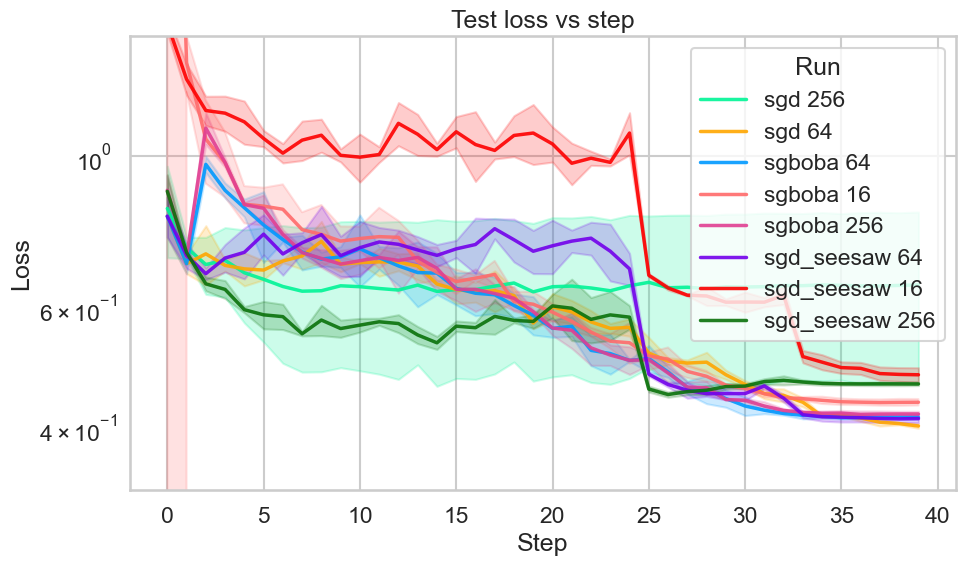

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 256": ["data/cifar10/sgd/basic/sgd-256-test.csv", 
                "data/cifar10/sgd/basic/256-test-seed1.csv",
                "data/cifar10/sgd/basic/256-test-seed2.csv"],
    "sgd 64": ["data/cifar10/sgd/basic/sgd-64-test.csv",
               "data/cifar10/sgd/basic/64-test-seed1.csv",
               "data/cifar10/sgd/basic/64-test-seed2.csv",
               ],
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2-test.csv",
                  "data/cifar10/sgd/aboba/64-test-seed1.csv",
                  "data/cifar10/sgd/aboba/64-test-seed2.csv"
                  ],
    "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-test-from-16.csv",
                  "data/cifar10/sgd/aboba/16-test-seed1.csv",
                  "data/cifar10/sgd/aboba/16-test-seed2.csv",
                  ],
    "sgboba 256": ["data/cifar10/sgd/aboba/sgd-aboba-test-from-256.csv",
                   "data/cifar10/sgd/aboba/256-test-seed1.csv",
                    "data/cifar10/sgd/aboba/256-test-seed2.csv",
                   ],
    "sgd_seesaw 64": ["data/cifar10/sgd/seesaw/sgd-seesaw-test-3.csv",
                      "data/cifar10/sgd/seesaw/64-test-seed1.csv",
                      "data/cifar10/sgd/seesaw/64-test-seed2.csv",
                      ],
    "sgd_seesaw 16": ["data/cifar10/sgd/seesaw/sgd-seesaw-3-test-from-16.csv",
                      "data/cifar10/sgd/seesaw/16-test-seed1.csv",
                      "data/cifar10/sgd/seesaw/16-test-seed2.csv"
                      ],
    "sgd_seesaw 256": ["data/cifar10/sgd/seesaw/sgd-seesaw-test-3-from-256.csv",
                        "data/cifar10/sgd/seesaw/256-test-seed1.csv",
                        "data/cifar10/sgd/seesaw/256-test-seed2.csv"
                       ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Test loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


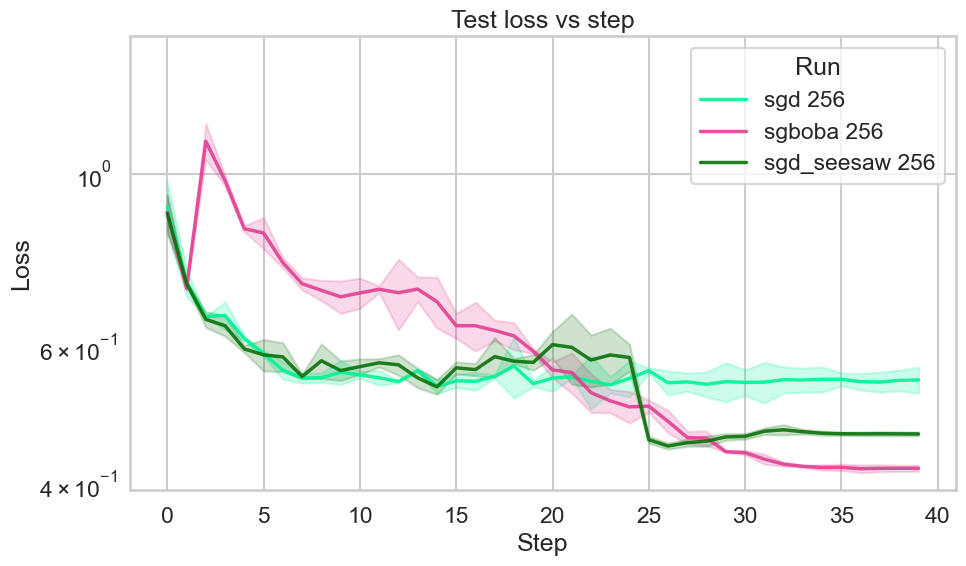

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 256": ["data/cifar10/sgd/basic/sgd-256-test.csv", 
                "data/cifar10/sgd/basic/256-test-seed1.csv",
                #"data/cifar10/sgd/basic/256-test-seed2.csv"
                ],
    "sgboba 256": ["data/cifar10/sgd/aboba/sgd-aboba-test-from-256.csv",
                   "data/cifar10/sgd/aboba/256-test-seed1.csv",
                    "data/cifar10/sgd/aboba/256-test-seed2.csv",
                   ],

    "sgd_seesaw 256": ["data/cifar10/sgd/seesaw/sgd-seesaw-test-3-from-256.csv",
                        "data/cifar10/sgd/seesaw/256-test-seed1.csv",
                        "data/cifar10/sgd/seesaw/256-test-seed2.csv"
                       ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Test loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


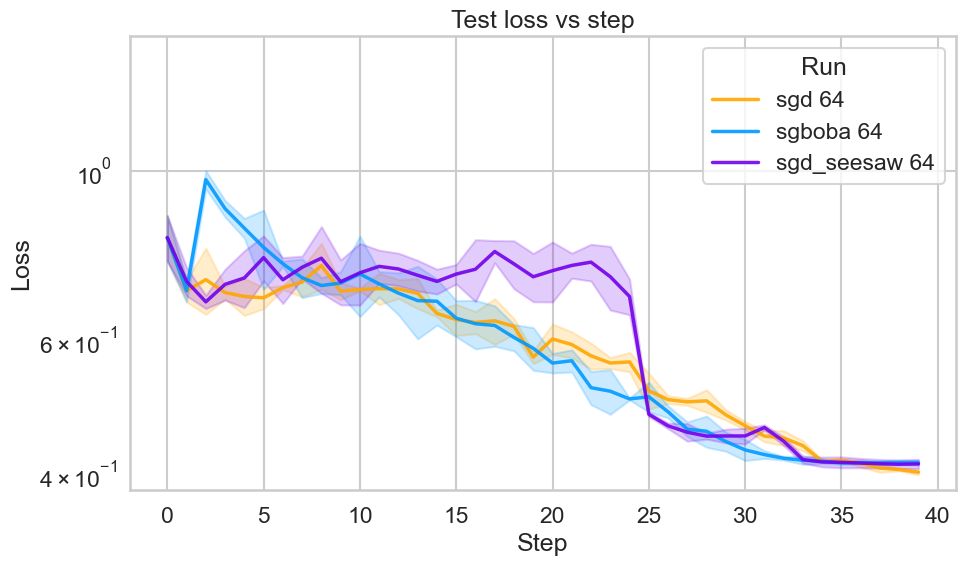

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 64": ["data/cifar10/sgd/basic/sgd-64-test.csv",
               "data/cifar10/sgd/basic/64-test-seed1.csv",
               "data/cifar10/sgd/basic/64-test-seed2.csv",
               ],
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2-test.csv",
                  "data/cifar10/sgd/aboba/64-test-seed1.csv",
                  "data/cifar10/sgd/aboba/64-test-seed2.csv"
                  ],
    "sgd_seesaw 64": ["data/cifar10/sgd/seesaw/sgd-seesaw-test-3.csv",
                      "data/cifar10/sgd/seesaw/64-test-seed1.csv",
                      "data/cifar10/sgd/seesaw/64-test-seed2.csv",
                      ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Test loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


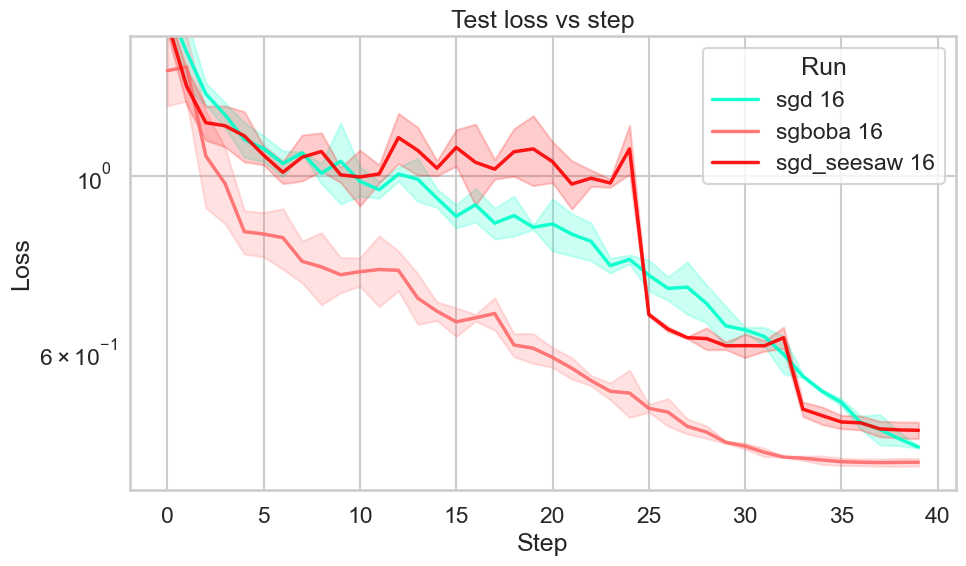

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 16": ["data/cifar10/sgd/basic/16-test-seed0.csv",
               "data/cifar10/sgd/basic/16-test-seed1.csv",
               "data/cifar10/sgd/basic/16-test-seed2.csv",
               ],
    "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-test-from-16.csv",
                  "data/cifar10/sgd/aboba/16-test-seed1.csv",
                  "data/cifar10/sgd/aboba/16-test-seed2.csv",
                  ],
    "sgd_seesaw 16": ["data/cifar10/sgd/seesaw/sgd-seesaw-3-test-from-16.csv",
                      "data/cifar10/sgd/seesaw/16-test-seed1.csv",
                      "data/cifar10/sgd/seesaw/16-test-seed2.csv"
                      ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Test loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


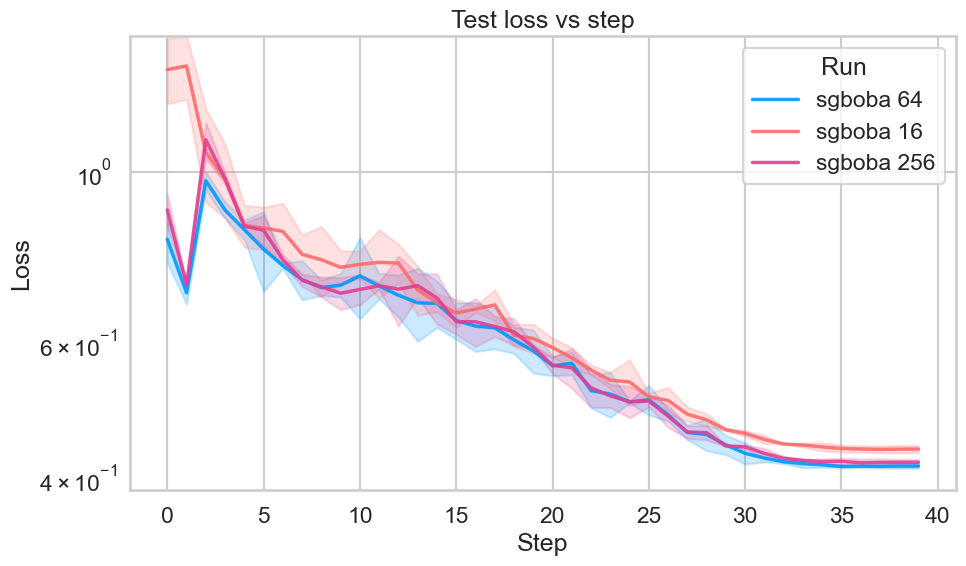

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2-test.csv",
                  "data/cifar10/sgd/aboba/64-test-seed1.csv",
                  "data/cifar10/sgd/aboba/64-test-seed2.csv"
                  ],
    "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-test-from-16.csv",
                  "data/cifar10/sgd/aboba/16-test-seed1.csv",
                  "data/cifar10/sgd/aboba/16-test-seed2.csv",
                  ],
    "sgboba 256": ["data/cifar10/sgd/aboba/sgd-aboba-test-from-256.csv",
                   "data/cifar10/sgd/aboba/256-test-seed1.csv",
                    "data/cifar10/sgd/aboba/256-test-seed2.csv",
                   ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Test loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


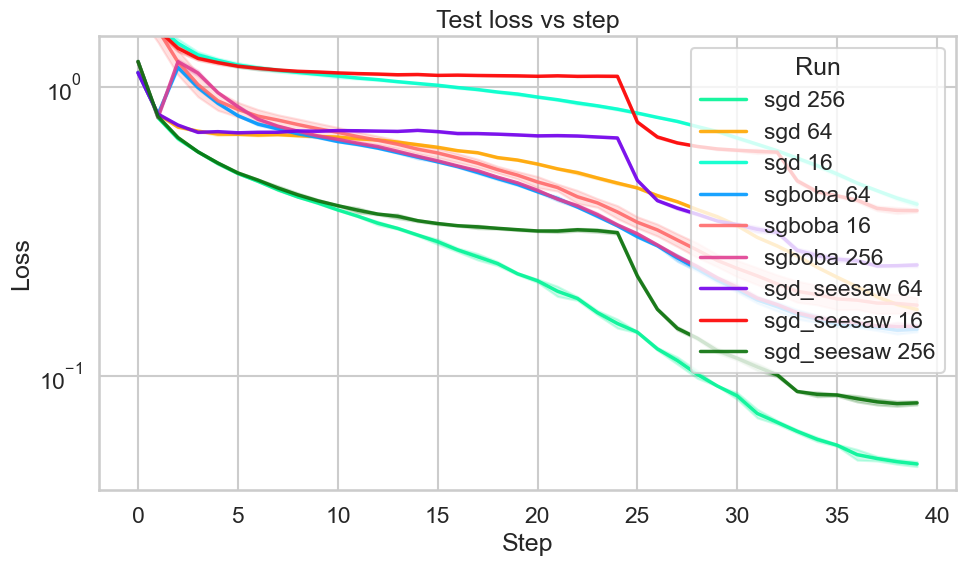

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 256": ["data/cifar10/sgd/basic/sgd-256.csv", 
                "data/cifar10/sgd/basic/256-train-seed1.csv",
                "data/cifar10/sgd/basic/256-train-seed2.csv"],
    "sgd 64": ["data/cifar10/sgd/basic/sgd-64.csv",
               "data/cifar10/sgd/basic/64-train-seed1.csv",
               "data/cifar10/sgd/basic/64-train-seed2.csv",
               ],
    "sgd 16": ["data/cifar10/sgd/basic/16-train-seed0.csv",
               "data/cifar10/sgd/basic/16-train-seed1.csv",
               "data/cifar10/sgd/basic/16-train-seed2.csv",
               ],
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2.csv",
                  "data/cifar10/sgd/aboba/64-train-seed1.csv",
                  "data/cifar10/sgd/aboba/64-train-seed2.csv"
                  ],
    "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-from-16.csv",
                  "data/cifar10/sgd/aboba/16-train-seed1.csv",
                  "data/cifar10/sgd/aboba/16-train-seed2.csv",
                  ],
    "sgboba 256": ["data/cifar10/sgd/aboba/sgd-aboba-from-256.csv",
                   "data/cifar10/sgd/aboba/256-train-seed1.csv",
                    "data/cifar10/sgd/aboba/256-train-seed2.csv",
                   ],
    "sgd_seesaw 64": [#"data/cifar10/sgd/seesaw/sgd-seesaw-3.csv",
                      "data/cifar10/sgd/seesaw/64-train-seed1.csv",
                      "data/cifar10/sgd/seesaw/64-train-seed2.csv",
                      ],
    "sgd_seesaw 16": ["data/cifar10/sgd/seesaw/sgd-seesaw-3-from-16.csv",
                      "data/cifar10/sgd/seesaw/16-train-seed1.csv",
                      "data/cifar10/sgd/seesaw/16-train-seed2.csv"
                      ],
    "sgd_seesaw 256": ["data/cifar10/sgd/seesaw/sgd-seesaw-3-from-256.csv",
                        "data/cifar10/sgd/seesaw/256-train-seed1.csv",
                        "data/cifar10/sgd/seesaw/256-train-seed2.csv"
                       ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


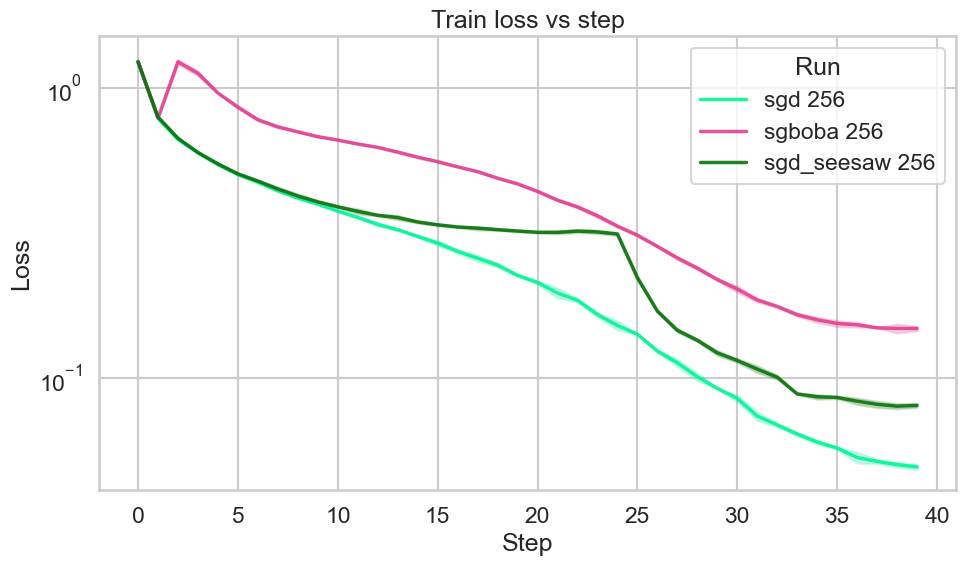

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 256": ["data/cifar10/sgd/basic/sgd-256.csv", 
                "data/cifar10/sgd/basic/256-train-seed1.csv",
                "data/cifar10/sgd/basic/256-train-seed2.csv"],
    "sgboba 256": ["data/cifar10/sgd/aboba/sgd-aboba-from-256.csv",
                   "data/cifar10/sgd/aboba/256-train-seed1.csv",
                    "data/cifar10/sgd/aboba/256-train-seed2.csv",
                   ],
    "sgd_seesaw 256": ["data/cifar10/sgd/seesaw/sgd-seesaw-3-from-256.csv",
                        "data/cifar10/sgd/seesaw/256-train-seed1.csv",
                        "data/cifar10/sgd/seesaw/256-train-seed2.csv"
                       ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


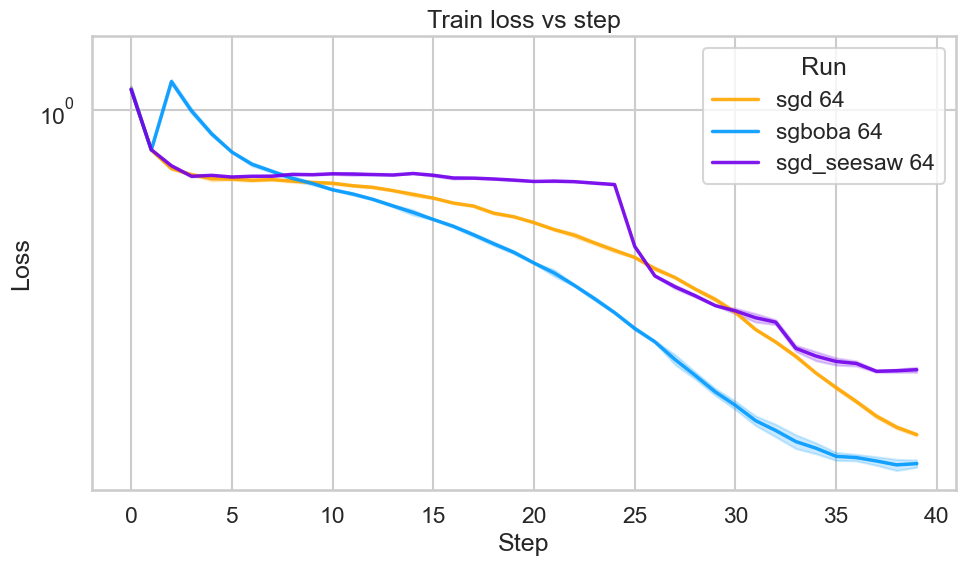

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 64": ["data/cifar10/sgd/basic/sgd-64.csv",
               "data/cifar10/sgd/basic/64-train-seed1.csv",
               "data/cifar10/sgd/basic/64-train-seed2.csv",
               ],
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2.csv",
                  "data/cifar10/sgd/aboba/64-train-seed1.csv",
                  "data/cifar10/sgd/aboba/64-train-seed2.csv"
                  ],
    "sgd_seesaw 64": [#"data/cifar10/sgd/seesaw/sgd-seesaw-3.csv",
                      "data/cifar10/sgd/seesaw/64-train-seed1.csv",
                      "data/cifar10/sgd/seesaw/64-train-seed2.csv",
                      ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


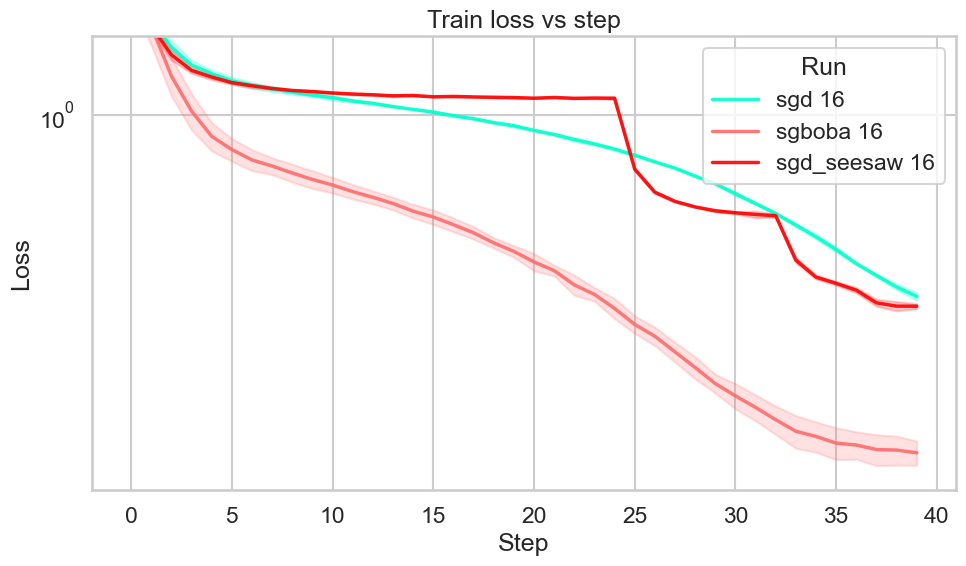

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgd 16": ["data/cifar10/sgd/basic/16-train-seed0.csv",
               "data/cifar10/sgd/basic/16-train-seed1.csv",
               "data/cifar10/sgd/basic/16-train-seed2.csv",
               ],
    "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-from-16.csv",
                  "data/cifar10/sgd/aboba/16-train-seed1.csv",
                  "data/cifar10/sgd/aboba/16-train-seed2.csv",
                  ],
    "sgd_seesaw 16": ["data/cifar10/sgd/seesaw/sgd-seesaw-3-from-16.csv",
                      "data/cifar10/sgd/seesaw/16-train-seed1.csv",
                      "data/cifar10/sgd/seesaw/16-train-seed2.csv"
                      ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


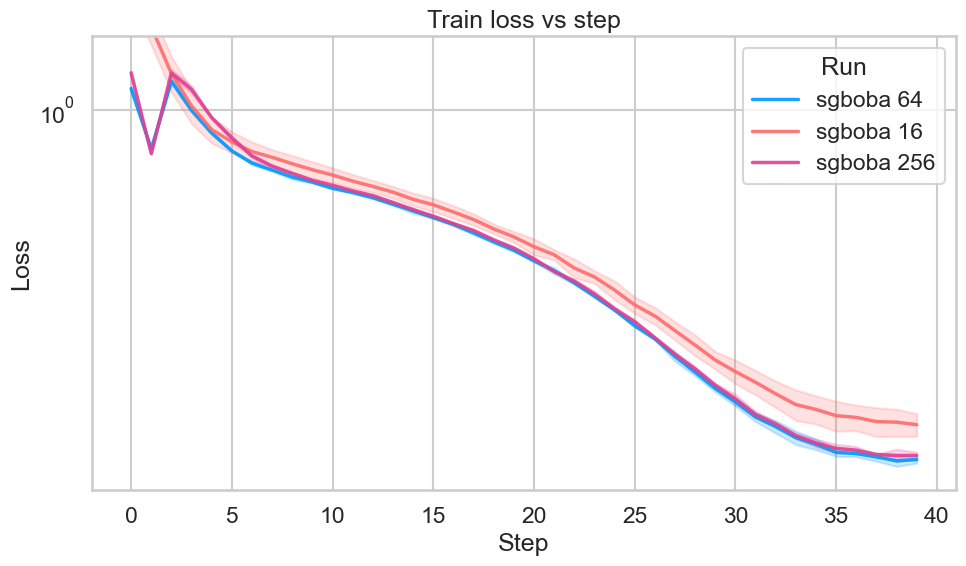

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2.csv",
                  "data/cifar10/sgd/aboba/64-train-seed1.csv",
                  "data/cifar10/sgd/aboba/64-train-seed2.csv"
                  ],
    "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-from-16.csv",
                  "data/cifar10/sgd/aboba/16-train-seed1.csv",
                  "data/cifar10/sgd/aboba/16-train-seed2.csv",
                  ],
    "sgboba 256": ["data/cifar10/sgd/aboba/sgd-aboba-from-256.csv",
                   "data/cifar10/sgd/aboba/256-train-seed1.csv",
                    "data/cifar10/sgd/aboba/256-train-seed2.csv",
                   ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Train loss vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper right")
ax.set_ylim(top=1.5)
plt.tight_layout()
plt.show()


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_19992/3100444468.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


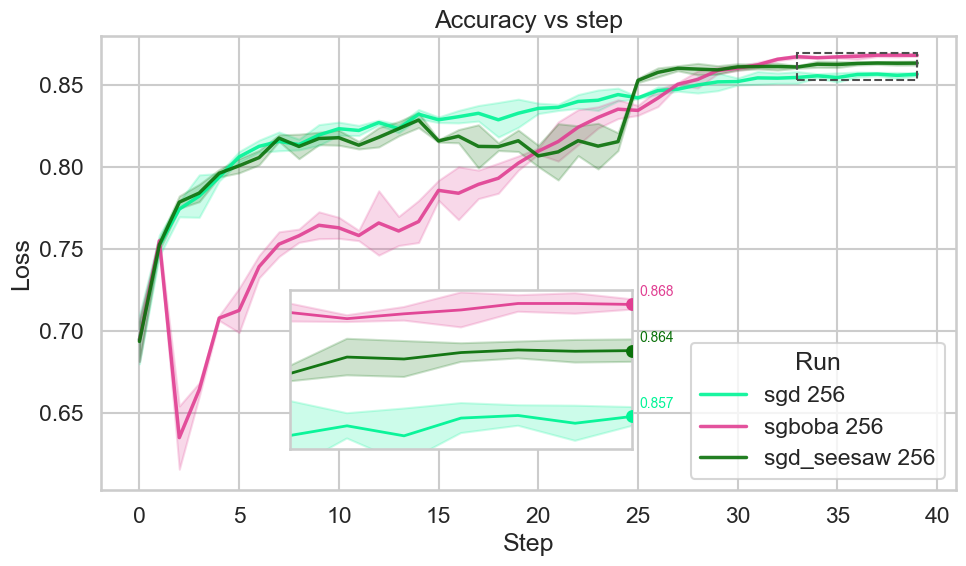

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

# -------------------- STYLE --------------------
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

# -------------------- DATA LOADING --------------------
def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

runs = {
    "sgd 256": [
        "data/cifar10/sgd/basic/sgd-256-acc.csv",
        "data/cifar10/sgd/basic/256-acc-seed1.csv",
        "data/cifar10/sgd/basic/256-acc-seed2.csv",
    ],
    "sgboba 256": [
        "data/cifar10/sgd/aboba/sgd-aboba-acc-from-256.csv",
        "data/cifar10/sgd/aboba/256-acc-seed1.csv",
        "data/cifar10/sgd/aboba/256-acc-seed2.csv",
    ],
    "sgd_seesaw 256": [
        "data/cifar10/sgd/seesaw/sgd-seesaw-acc-3-from-256.csv",
        "data/cifar10/sgd/seesaw/256-acc-seed1.csv",
        "data/cifar10/sgd/seesaw/256-acc-seed2.csv",
    ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))

df = pd.concat(frames, ignore_index=True)

# -------------------- MAIN PLOT --------------------
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(
    title="Accuracy vs step",
    xlabel="Step",
    ylabel="Loss",
)
ax.legend(title="Run", loc="lower right")
ax.set_ylim(top=0.88)

# -------------------- INSET (LOUPE) --------------------
axins = inset_axes(
    ax,
    width="40%",
    height="35%",
    loc="lower left",
    bbox_to_anchor=(0.2, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.8,
)

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.0,
    alpha=0.95,
    legend=False,
    ax=axins,
)

# -------------------- AUTO SCALE FOR INSET --------------------
window = 6
x1 = float(df["step"].max())
x0 = x1 - window

mean_df = (
    df.groupby(["run", "step"], as_index=False)["value"]
    .mean()
)

zoom_df = mean_df.query("@x0 <= step <= @x1")

if not zoom_df.empty:
    y_min = float(zoom_df["value"].min())
    y_max = float(zoom_df["value"].max())

    dy = y_max - y_min
    pad = 0.1 * dy if dy > 0 else 0.01

    y0 = y_min - pad
    y1 = y_max + pad

    axins.set_xlim(x0, x1)
    axins.set_ylim(y0, y1)

    # ---- RECTANGLE: область увеличения ----
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=1.5,
        edgecolor="0.3",
        facecolor="none",
        linestyle="--",
        zorder=3,
    )
    ax.add_patch(rect)

# -------------------- INSET CLEANUP --------------------
axins.set_xlabel("")
axins.set_ylabel("")
axins.grid(False)

axins.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

# точки и подписи последних mean-значений
for name, group in df.groupby("run"):
    mean_by_step = (
        group.sort_values("step")
        .groupby("step", as_index=False)["value"]
        .mean()
    )
    last = mean_by_step.iloc[-1]
    x, y = float(last["step"]), float(last["value"])

    if (
        axins.get_xlim()[0] <= x <= axins.get_xlim()[1]
        and axins.get_ylim()[0] <= y <= axins.get_ylim()[1]
    ):
        axins.scatter(x, y, color=palette[name], s=60, zorder=5)
        axins.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 4),
            ha="left",
            va="bottom",
            color=palette[name],
            fontsize=10,
            zorder=6,
        )

# -------------------- FINALIZE --------------------
plt.tight_layout()
plt.show()


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_19067/4131324809.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


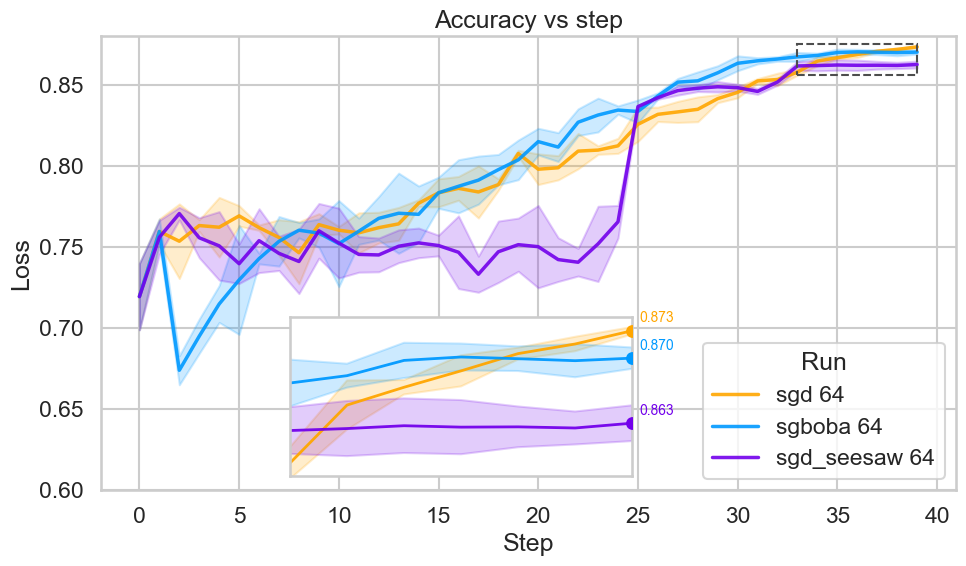

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

# -------------------- STYLE --------------------
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

# -------------------- DATA LOADING --------------------
def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

runs = {
    "sgd 64": [
        "data/cifar10/sgd/basic/sgd-64-acc.csv",
        "data/cifar10/sgd/basic/64-acc-seed1.csv",
        "data/cifar10/sgd/basic/64-acc-seed2.csv",
    ],
    "sgboba 64": [
        "data/cifar10/sgd/aboba/sgd-aboba-2-acc.csv",
        "data/cifar10/sgd/aboba/64-acc-seed1.csv",
        "data/cifar10/sgd/aboba/64-acc-seed2.csv",
    ],
    "sgd_seesaw 64": [
        "data/cifar10/sgd/seesaw/sgd-seesaw-acc-3.csv",
        "data/cifar10/sgd/seesaw/64-acc-seed1.csv",
        "data/cifar10/sgd/seesaw/64-acc-seed2.csv",
    ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))

df = pd.concat(frames, ignore_index=True)

# -------------------- MAIN PLOT --------------------
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(
    title="Accuracy vs step",
    xlabel="Step",
    ylabel="Loss",
)
ax.legend(title="Run", loc="lower right")
ax.set_ylim(bottom=0.6,top=0.88)

# -------------------- INSET (LOUPE) --------------------
axins = inset_axes(
    ax,
    width="40%",
    height="35%",
    loc="lower left",
    bbox_to_anchor=(0.2, -0.01, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.8,
)

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.0,
    alpha=0.95,
    legend=False,
    ax=axins,
)

# -------------------- AUTO SCALE FOR INSET --------------------
window = 6
x1 = float(df["step"].max())
x0 = x1 - window

mean_df = (
    df.groupby(["run", "step"], as_index=False)["value"]
    .mean()
)

zoom_df = mean_df.query("@x0 <= step <= @x1")

if len(zoom_df) > 0:
    y_min = float(zoom_df["value"].min())
    y_max = float(zoom_df["value"].max())

    dy = y_max - y_min
    pad = 0.1 * dy if dy > 0 else 0.01

    y0 = y_min - pad
    y1 = y_max + pad

    axins.set_xlim(x0, x1)
    axins.set_ylim(y0, y1)

    # -------------------- ZOOM AREA RECTANGLE --------------------
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=1.5,
        edgecolor="0.3",
        facecolor="none",
        linestyle="--",
        zorder=3,
    )
    ax.add_patch(rect)

# -------------------- INSET CLEANUP --------------------
axins.set_xlabel("")
axins.set_ylabel("")
axins.grid(False)

axins.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

# точки и подписи последних mean-значений
for name, group in df.groupby("run"):
    mean_by_step = (
        group.sort_values("step")
        .groupby("step", as_index=False)["value"]
        .mean()
    )
    last = mean_by_step.iloc[-1]
    x, y = float(last["step"]), float(last["value"])

    if (
        axins.get_xlim()[0] <= x <= axins.get_xlim()[1]
        and axins.get_ylim()[0] <= y <= axins.get_ylim()[1]
    ):
        axins.scatter(x, y, color=palette[name], s=60, zorder=5)
        axins.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 4),
            ha="left",
            va="bottom",
            color=palette[name],
            fontsize=10,
            zorder=6,
        )

# -------------------- FINALIZE --------------------
plt.tight_layout()
plt.show()


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_19067/1505683624.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


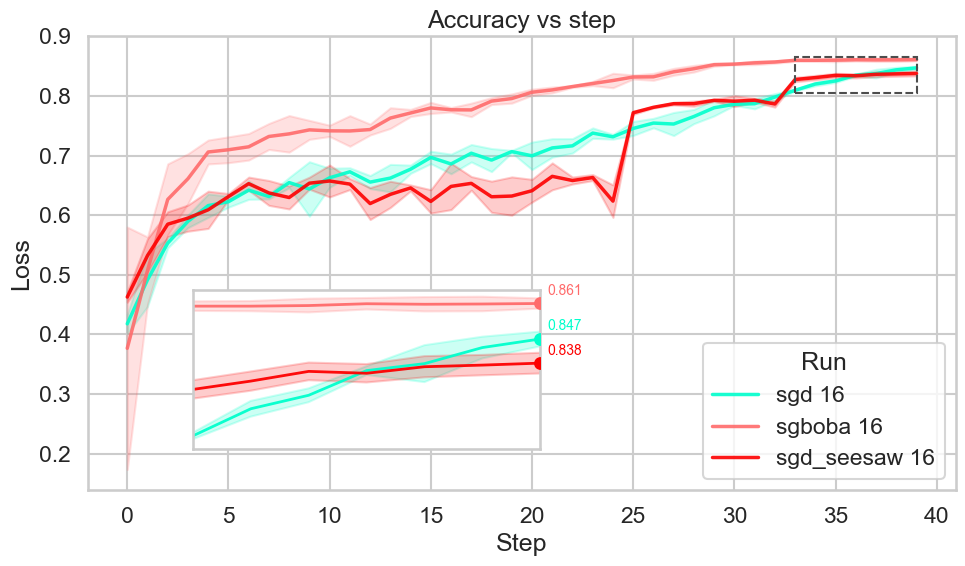

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

# -------------------- STYLE --------------------
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

# -------------------- DATA LOADING --------------------
def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

runs = {
    "sgd 16": [
        "data/cifar10/sgd/basic/16-acc-seed0.csv",
        "data/cifar10/sgd/basic/16-acc-seed1.csv",
        "data/cifar10/sgd/basic/16-acc-seed2.csv",
    ],
    "sgboba 16": [
        "data/cifar10/sgd/aboba/sgd-aboba-acc-from-16.csv",
        "data/cifar10/sgd/aboba/16-acc-seed1.csv",
        "data/cifar10/sgd/aboba/16-acc-seed2.csv",
    ],
    "sgd_seesaw 16": [
        "data/cifar10/sgd/seesaw/sgd-seesaw-3-acc-from-16.csv",
        "data/cifar10/sgd/seesaw/16-acc-seed1.csv",
        "data/cifar10/sgd/seesaw/16-acc-seed2.csv",
    ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))

df = pd.concat(frames, ignore_index=True)

# -------------------- MAIN PLOT --------------------
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(
    title="Accuracy vs step",
    xlabel="Step",
    ylabel="Loss",
)
ax.legend(title="Run", loc="lower right")
ax.set_ylim(top=0.9)

# -------------------- INSET (LOUPE) --------------------
axins = inset_axes(
    ax,
    width="40%",
    height="35%",
    loc="lower left",
    bbox_to_anchor=(0.1, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.8,
)

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.0,
    alpha=0.95,
    legend=False,
    ax=axins,
)

# -------------------- AUTO SCALE FOR INSET --------------------
window = 6
x1 = float(df["step"].max())
x0 = x1 - window

mean_df = (
    df.groupby(["run", "step"], as_index=False)["value"]
    .mean()
)

zoom_df = mean_df.query("@x0 <= step <= @x1")

if not zoom_df.empty:
    y_min = float(zoom_df["value"].min())
    y_max = float(zoom_df["value"].max())

    dy = y_max - y_min
    pad = 0.1 * dy if dy > 0 else 0.01

    y0 = y_min - pad
    y1 = y_max + pad

    axins.set_xlim(x0, x1)
    axins.set_ylim(y0, y1)

    # ---- RECTANGLE: область увеличения ----
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=1.5,
        edgecolor="0.3",
        facecolor="none",
        linestyle="--",
        zorder=3,
    )
    ax.add_patch(rect)

# -------------------- INSET CLEANUP --------------------
axins.set_xlabel("")
axins.set_ylabel("")
axins.grid(False)

axins.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

# точки и подписи последних mean-значений
for name, group in df.groupby("run"):
    mean_by_step = (
        group.sort_values("step")
        .groupby("step", as_index=False)["value"]
        .mean()
    )
    last = mean_by_step.iloc[-1]
    x, y = float(last["step"]), float(last["value"])

    if (
        axins.get_xlim()[0] <= x <= axins.get_xlim()[1]
        and axins.get_ylim()[0] <= y <= axins.get_ylim()[1]
    ):
        axins.scatter(x, y, color=palette[name], s=60, zorder=5)
        axins.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 4),
            ha="left",
            va="bottom",
            color=palette[name],
            fontsize=10,
            zorder=6,
        )

# -------------------- FINALIZE --------------------
plt.tight_layout()
plt.show()


/var/folders/fw/_g62j85x4r934wtl7_x64hcc0000gn/T/ipykernel_19067/2393175062.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


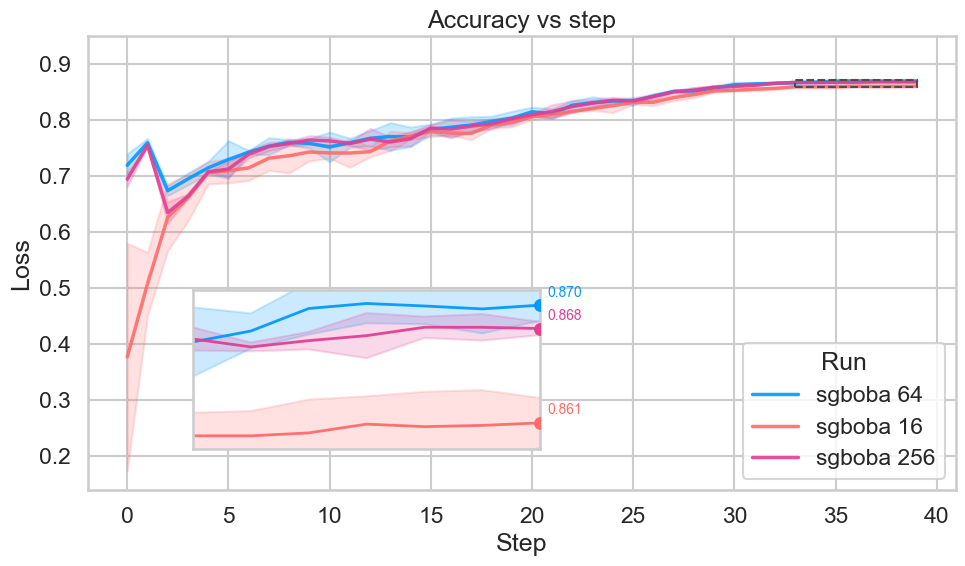

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

# -------------------- STYLE --------------------
sns.set_theme(style="whitegrid", context="talk")

palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

# -------------------- DATA LOADING --------------------
def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

runs = {
    "sgboba 64": [
        "data/cifar10/sgd/aboba/sgd-aboba-2-acc.csv",
        "data/cifar10/sgd/aboba/64-acc-seed1.csv",
        "data/cifar10/sgd/aboba/64-acc-seed2.csv",
    ],
    "sgboba 16": [
        "data/cifar10/sgd/aboba/sgd-aboba-acc-from-16.csv",
        "data/cifar10/sgd/aboba/16-acc-seed1.csv",
        "data/cifar10/sgd/aboba/16-acc-seed2.csv",
    ],
    "sgboba 256": [
        "data/cifar10/sgd/aboba/sgd-aboba-acc-from-256.csv",
        "data/cifar10/sgd/aboba/256-acc-seed1.csv",
        "data/cifar10/sgd/aboba/256-acc-seed2.csv",
    ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))

df = pd.concat(frames, ignore_index=True)

# -------------------- MAIN PLOT --------------------
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(
    title="Accuracy vs step",
    xlabel="Step",
    ylabel="Loss",
)
ax.legend(title="Run", loc="lower right")
ax.set_ylim(top=0.95)

# -------------------- INSET (LOUPE) --------------------
axins = inset_axes(
    ax,
    width="40%",
    height="35%",
    loc="lower left",
    bbox_to_anchor=(0.1, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0.8,
)

sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",
    lw=2.0,
    alpha=0.95,
    legend=False,
    ax=axins,
)

# -------------------- AUTO SCALE FOR INSET --------------------
window = 6
x1 = float(df["step"].max())
x0 = x1 - window

mean_df = (
    df.groupby(["run", "step"], as_index=False)["value"]
    .mean()
)

zoom_df = mean_df.query("@x0 <= step <= @x1")

if not zoom_df.empty:
    y_min = float(zoom_df["value"].min())
    y_max = float(zoom_df["value"].max())

    dy = y_max - y_min
    pad = 0.1 * dy if dy > 0 else 0.01

    y0 = y_min - pad
    y1 = y_max + pad

    axins.set_xlim(x0, x1)
    axins.set_ylim(y0, y1)

    # ---- RECTANGLE: область увеличения ----
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=1.5,
        edgecolor="0.3",
        facecolor="none",
        linestyle="--",
        zorder=3,
    )
    ax.add_patch(rect)

# -------------------- INSET CLEANUP --------------------
axins.set_xlabel("")
axins.set_ylabel("")
axins.grid(False)

axins.tick_params(
    axis="both",
    which="both",
    bottom=False,
    left=False,
    labelbottom=False,
    labelleft=False,
)

# точки и подписи последних mean-значений
for name, group in df.groupby("run"):
    mean_by_step = (
        group.sort_values("step")
        .groupby("step", as_index=False)["value"]
        .mean()
    )
    last = mean_by_step.iloc[-1]
    x, y = float(last["step"]), float(last["value"])

    if (
        axins.get_xlim()[0] <= x <= axins.get_xlim()[1]
        and axins.get_ylim()[0] <= y <= axins.get_ylim()[1]
    ):
        axins.scatter(x, y, color=palette[name], s=60, zorder=5)
        axins.annotate(
            f"{y:.3f}",
            (x, y),
            textcoords="offset points",
            xytext=(5, 4),
            ha="left",
            va="bottom",
            color=palette[name],
            fontsize=10,
            zorder=6,
        )

# -------------------- FINALIZE --------------------
plt.tight_layout()
plt.show()


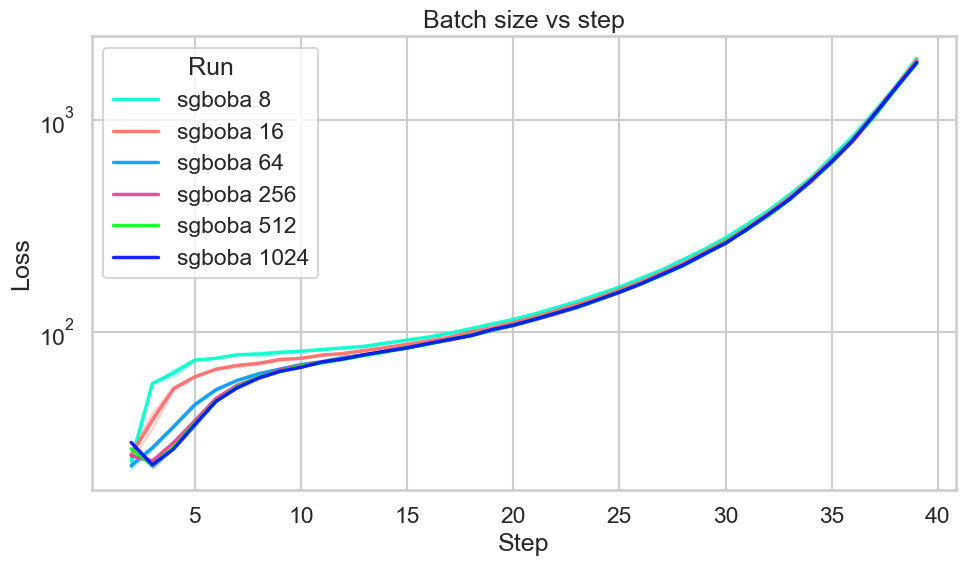

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",

    "sgboba 8": "#00ffcc",
    "sgboba 512": "#00ff1a",
    "sgboba 1024": "#000dff",

}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgboba 8": ["data/cifar10/sgd/aboba/8-bs-seed0.csv",
                   "data/cifar10/sgd/aboba/8-bs-seed1.csv",
                   ],
    "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-bs-from-16.csv",
                  "data/cifar10/sgd/aboba/16-bs-seed1.csv",
                  "data/cifar10/sgd/aboba/16-bs-seed2.csv",
                  ],
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2-bs.csv",
                  "data/cifar10/sgd/aboba/64-bs-seed1.csv",
                  "data/cifar10/sgd/aboba/64-bs-seed2.csv"
                  ],
    "sgboba 256": [#"data/cifar10/sgd/aboba/sgd-aboba-bs-from-256.csv",
                   "data/cifar10/sgd/aboba/256-bs-seed1.csv",
                    "data/cifar10/sgd/aboba/256-bs-seed2.csv",
                   ],
    
    "sgboba 512": ["data/cifar10/sgd/aboba/512-bs-seed0.csv",
                   "data/cifar10/sgd/aboba/512-bs-seed1.csv",
                   ],
    "sgboba 1024": ["data/cifar10/sgd/aboba/1024-bs-seed0.csv",
                   "data/cifar10/sgd/aboba/1024-bs-seed1.csv",
                   ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Batch size vs step", xlabel="Step", ylabel="Loss", yscale="log")
ax.legend(title="Run", loc="upper left")
#ax.set_ylim(top=0.95)
plt.tight_layout()
plt.show()


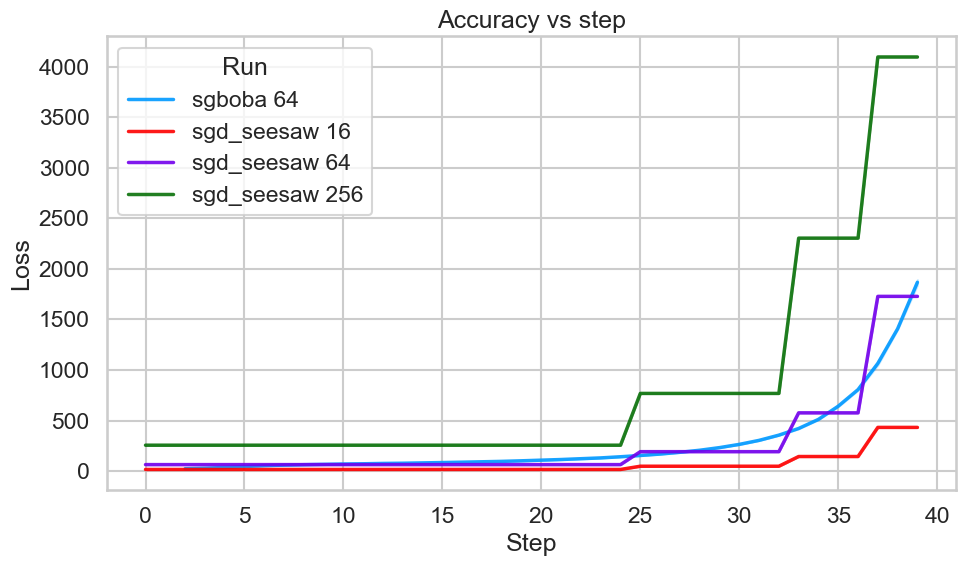

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
palette = {
    "sgboba 64": "#0099ff",
    "sgboba 16": "#ff6b6b",
    "sgboba 256": "#e03f92",
    "sgd_seesaw 64": "#7200eb",
    "sgd_seesaw 16": "#fd0000",
    "sgd_seesaw 256": "#0a710a",
    "sgd 256": "#00f496",
    "sgd 64": "#ffa600",
    "sgd 16": "#00ffcc",
}

def load_loss(path, run_name, seed_name):
    df = pd.read_csv(path, usecols=["step", "value"])
    df["run"] = run_name
    df["seed"] = seed_name
    return df

# Заполни списки путей для каждого run (любые имена файлов)
runs = {
    "sgboba 64": ["data/cifar10/sgd/aboba/sgd-aboba-2-bs.csv",
                  "data/cifar10/sgd/aboba/64-bs-seed1.csv",
                  "data/cifar10/sgd/aboba/64-bs-seed2.csv"
                  ],
    # "sgboba 16": ["data/cifar10/sgd/aboba/sgd-aboba-bs-from-16.csv",
    #               "data/cifar10/sgd/aboba/16-bs-seed1.csv",
    #               "data/cifar10/sgd/aboba/16-bs-seed2.csv",
    #               ],
    # "sgboba 256": [#"data/cifar10/sgd/aboba/sgd-aboba-bs-from-256.csv",
    #                "data/cifar10/sgd/aboba/256-bs-seed1.csv",
    #                 "data/cifar10/sgd/aboba/256-bs-seed2.csv",
    #                ],
    "sgd_seesaw 16": ["data/cifar10/sgd/seesaw/sgd-seesaw-3-bs-from-16.csv",
                      "data/cifar10/sgd/seesaw/16-bs-seed1.csv",
                      "data/cifar10/sgd/seesaw/16-bs-seed2.csv"
                      ],
    "sgd_seesaw 64": ["data/cifar10/sgd/seesaw/sgd-seesaw-bs-3.csv",
                      "data/cifar10/sgd/seesaw/64-bs-seed1.csv",
                      "data/cifar10/sgd/seesaw/64-bs-seed2.csv",
                      ],
    "sgd_seesaw 256": ["data/cifar10/sgd/seesaw/sgd-seesaw-bs-3-from-256.csv",
                        "data/cifar10/sgd/seesaw/256-bs-seed1.csv",
                        "data/cifar10/sgd/seesaw/256-bs-seed2.csv"
                       ],
}

frames = []
for run_name, paths in runs.items():
    for i, path in enumerate(paths, start=1):
        frames.append(load_loss(path, run_name, f"seed{i}"))
df = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="step",
    y="value",
    hue="run",
    palette=palette,
    estimator="mean",
    errorbar="sd",      # стандартное отклонение
    lw=2.5,
    alpha=0.9,
    ax=ax,
)

ax.set(title="Accuracy vs step", xlabel="Step", ylabel="Loss",)# yscale="log")
ax.legend(title="Run", loc="upper left")
#ax.set_ylim(top=0.95)
plt.tight_layout()
plt.show()
